In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV

In [20]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset.csv')
df.head()

,address_line_2,address_locality,h_id,n_atm_in_1km,n_atm_in_1km_to_2km,n_atm_in_2km_to_3km,n_atm_in_3km_to_5km,n_university_in_2km_to_3km,near_AEON_Mall_3_in_km,near_Phnom_Penh_Airport_in_km,price_per_m2
0,78.0,5.0,450.0,10.0,25.0,50.0,497.0,47.0,8.085684,3.942955,3249.773855
1,48.0,0.0,476.0,10.0,30.0,75.0,510.0,10.0,3.893582,7.980455,2357.960918
2,45.0,10.0,351.0,10.0,30.0,72.0,502.0,40.0,11.097599,6.130610,3466.326691
3,45.0,10.0,464.0,10.0,65.0,127.0,558.0,18.0,10.042650,5.951667,2979.374452
4,14.0,4.0,427.0,0.0,0.0,35.0,524.0,3.0,9.083886,13.113004,5133.654419


In [21]:
df.shape    

(9272, 11)

In [22]:
# df.dropduplicates(inplace=True)

In [23]:
X = df.drop('price_per_m2', axis=1)
y = df['price_per_m2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
model = LinearRegression()

param_space = {
    'copy_X': [True, False],
    'fit_intercept': [True, False],
    'n_jobs': [None, 1, -1],
    'positive': [True, False]
}

random_search = RandomizedSearchCV(model, param_space, n_iter=10, cv=5)
random_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}") 

Best Hyperparameters: {'positive': False, 'n_jobs': -1, 'fit_intercept': True, 'copy_X': True}
Best Score: 0.7731093910183124


In [25]:
# from math import sqrt

# # Lists to store training and validation losses
# train_losses = []
# val_losses = []

# # Train the model over a range of epochs
# epochs = range(1, 101)
# for epoch in epochs:
#     random_search.fit(X_train, y_train)
    
#     # Predict and calculate the training loss
#     train_pred = random_search.predict(X_train)
#     train_loss = r2_score(y_train, train_pred)
#     train_losses.append(train_loss)
    
#     # Predict and calculate
#     # Predict and calculate the validation loss
#     val_pred = random_search.predict(X_test)
#     val_loss = r2_score(y_test, val_pred)
#     val_losses.append(val_loss)

# # Plotting the learning curve
# plt.figure(figsize=(10, 6))
# plt.plot(epochs, train_losses, label='Training RMSE')
# plt.plot(epochs, val_losses, label='Validation RMSE', linestyle='--')
# plt.title('Learning Curve')
# plt.xlabel('Epochs')
# plt.ylabel('R2 score')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()

In [26]:
# Make predictions
y_pred = random_search.predict(X_test)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.3f}")  # Closer to 1.0 is better
print(f"RMSE: {rmse:.2f}")     # Lower is better


R² Score: 0.768
RMSE: 891.50


In [27]:
# Evaluate on training set
y_train_pred = random_search.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

print(f"Train R² Score: {r2_train:.3f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test R² Score: {r2:.3f}")
print(f"Test RMSE: {rmse:.2f}")

Train R² Score: 0.774
Train RMSE: 902.64
Test R² Score: 0.768
Test RMSE: 891.50


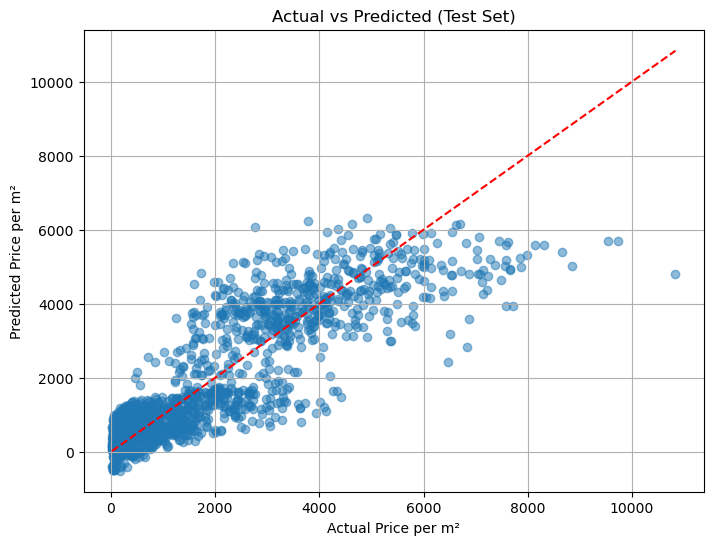

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price per m²")
plt.ylabel("Predicted Price per m²")
plt.title("Actual vs Predicted (Test Set)")
plt.grid(True)
plt.show()

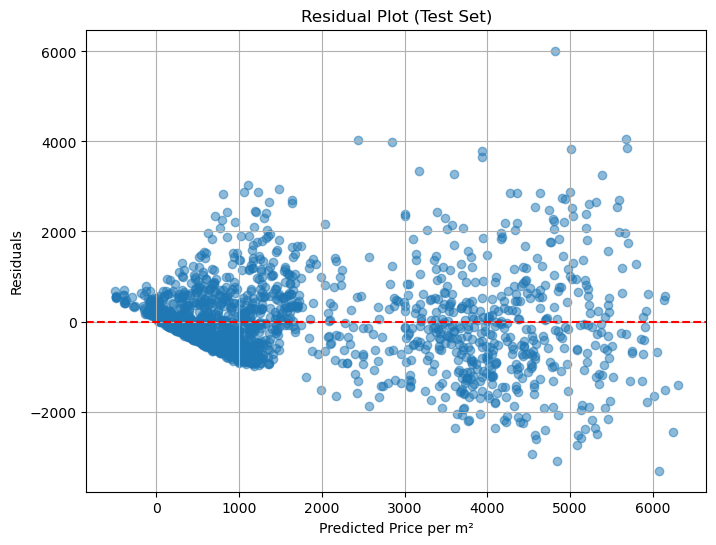

In [29]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price per m²")
plt.ylabel("Residuals")
plt.title("Residual Plot (Test Set)")
plt.grid(True)
plt.show()

In [30]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(random_search, X, y, cv=5, scoring='r2')

print("Cross-validated R² scores:", cv_scores)
print("Mean R²:", np.mean(cv_scores))
print("Std R²:", np.std(cv_scores))

Cross-validated R² scores: [0.03873679 0.69513944 0.68204453 0.55185513 0.49465048]
Mean R²: 0.49248527357137045
Std R²: 0.2393401671700391


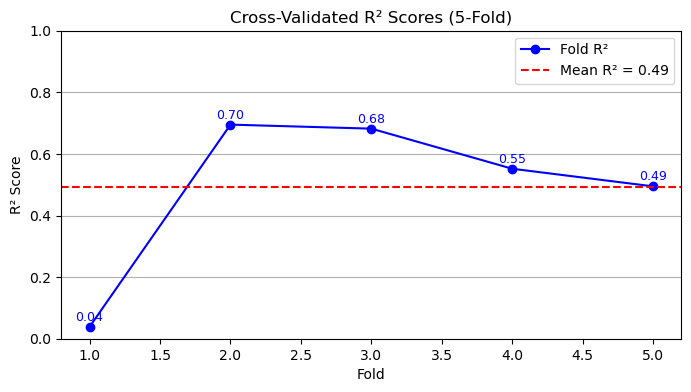

In [31]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set number of folds
cv_folds = 5 
plt.figure(figsize=(8, 4))
plt.plot(range(1, cv_folds + 1), cv_scores, marker='o', linestyle='-', color='blue', label='Fold R²')

for i, score in enumerate(cv_scores):
    plt.text(i + 1, score + 0.01, f"{score:.2f}", ha='center', va='bottom', fontsize=9, color='blue')

# Plot mean R² as a horizontal dashed line
mean_r2 = np.mean(cv_scores)
plt.axhline(mean_r2, color='red', linestyle='--', label=f"Mean R² = {mean_r2:.2f}")

plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title(f"Cross-Validated R² Scores ({cv_folds}-Fold)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='y')
plt.show()

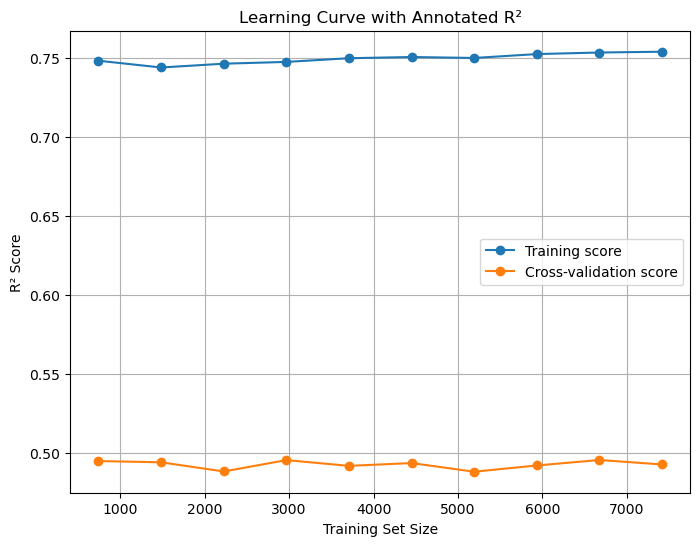

In [32]:
y = df['price_per_m2']

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='r2', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=42
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', label="Cross-validation score")

plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve with Annotated R²")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [33]:
# Calculate all required metrics
def calculate_metrics(model, X_train, y_train, X_test, y_test, model_name="Linear Regression", cv_folds=5):
    # Train set predictions
    y_pred_train = model.predict(X_train)
    
    # Test set predictions
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics for test set
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mape = np.mean(np.abs((y_test - y_pred_test) / np.maximum(np.abs(y_test), 1))) * 100
    
    # Calculate train R2
    train_r2 = r2_score(y_train, y_pred_train)
    
  
    
    # Create metrics dataframe
    metrics_df = pd.DataFrame({
        'Metric': ['R2(Test)', 'MAE', 'RMSE', 'MAPE', 'Train R2'],
        'Value': [test_r2, test_mae, test_rmse, test_mape, train_r2]
    })
    
    # Add model name column
    metrics_df['Model'] = model_name
    
    return metrics_df.round(4)

In [34]:
linreg_metrics = calculate_metrics(random_search, X_train, y_train, X_test, y_test)
print("\nLinear Regression Performance Metrics:")
print("="*60)
print(linreg_metrics.to_string(index=False))
print("="*60)


Linear Regression Performance Metrics:
  Metric    Value             Model
R2(Test)   0.7676 Linear Regression
     MAE 633.5192 Linear Regression
    RMSE 891.5026 Linear Regression
    MAPE 137.7031 Linear Regression
Train R2   0.7739 Linear Regression


In [35]:
import joblib
# joblib.dump(random_search, "../../../models/linear_regression/linear_regression_model_v3.joblib")